# SCALib TVLA 입문

## 학습 목표

**TVLA**(Test Vector Leakage Assessment)는 부채널 파형에서 **비밀과 관련된 정보가 새는지**를 점검하는 방법이다.  
키를 복원하는 공격(CPA 등)이 아니라, 두 집단의 파형이 통계적으로 다른지 보는 **누설 진단**이다.

이 노트북 하나만 위에서 아래로 실행하면, 오픈소스 라이브러리 **SCALib**의 TVLA 기능(`scalib.metrics.Ttest`, `MTtest`)을 이해할 수 있다.  
하드웨어 없이 **시뮬 파형**으로 전 과정을 재현한다.

### 진행 순서

| 단계 | 내용 |
|:----:|:-----|
| 1 | SCALib를 설치한다 |
| 2 | TVLA와 Welch t-test 개념을 정리한다 |
| 3 | `Ttest`의 입력 형식과 호출 순서를 익힌다 |
| 4 | 시뮬 파형을 생성한다 |
| 5 | fixed-key vs random-key TVLA를 실행한다 |
| 6 | 그래프를 해석하고 노이즈 영향을 본다 |
| 7 | (확장) `MTtest`와 자기 파형 적용 방법을 본다 |


---
## 1. SCALib 설치

SCALib의 PyPI 패키지 이름은 **`scalib`**이다.

```text
pip install scalib
```

### 이 환경(chipwhisperer-kor, Python 3.9)에서의 버전

| SCALib | 최소 Python | Python 3.9 |
|--------|-------------|------------|
| **0.6.0** 이하 | 3.9를 지원한다 | 설치할 수 있다 |
| **0.6.1** 이상 | 3.10 이상이다 | 설치할 수 없다 |

그래서 아래 셀은 **`scalib>=0.6.0,<0.6.1`**로 설치한다.  
이미 설치되어 있으면 다시 실행해도 된다.

설치 후 `import scalib`로 버전을 확인한다. 이 노트북은 **PyPI에서 설치한 `scalib` 패키지**만 사용한다.


In [1]:
%pip install -q "scalib>=0.6.0,<0.6.1"


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import scalib
from scalib.metrics import Ttest

# chipwhisperer-kor 이미지의 fonts-nanum으로 그래프 한글·마이너스 깨짐을 완화한다.
matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

print("Python :", sys.version.split()[0])
print("NumPy  :", np.__version__)
print("SCALib :", scalib.__version__)
print("위치   :", scalib.__file__)


Python : 3.9.25
NumPy  : 1.26.4
SCALib : 0.6.0
위치   : /usr/local/lib/python3.9/site-packages/scalib/__init__.py


---
## 2. TVLA가 하는 일

### 2.1 직관

1. 같은 측정 설정으로 파형을 많이 모은다.
2. 입력을 **두 집단**으로 나눈다. 예는 다음과 같다.
   - 집단 0: 키가 **매번 랜덤**이다.
   - 집단 1: 키가 **항상 동일(고정)**이다.
   - 평문은 두 집단 모두 **동일하게 고정**한다 (이 노트북의 시나리오).
3. 파형의 **각 샘플 시점**마다, 두 집단 값의 평균이 같은지 **Welch t-test**로 검사한다.

```text
트레이스 (행) × 샘플 시점 (열)

  집단0  [  .  .  *  .  .  ]
  집단0  [  .  .  *  .  .  ]
  집단1  [  .  .  *  .  .  ]
  집단1  [  .  .  *  .  .  ]
              ↑
         이 시점 j에서
         집단0 값들 vs 집단1 값들 → t_j
```

시점 \(j\)에서의 t 통계량은 다음과 같다.

\[
t_j = \frac{\mu_{0,j} - \mu_{1,j}}{\sqrt{\frac{v_{0,j}}{n_0} + \frac{v_{1,j}}{n_1}}}
\]

- \(\mu\): 표본 평균, \(v\): 분산, \(n\): 그 집단의 트레이스 수
- **|t|가 크면**: 그 시점에서 두 집단이 달라 보인다. 곧 **누설 후보 시점**이다.

### 2.2 임계값 ±4.5

그래프에 **|t| = 4.5** 수평선을 자주 긋는다. 관례적인 **경보선**이다.

| 관찰 | 올바른 해석 |
|------|-------------|
| \|t\| > 4.5 | 우연만으로 보기 어려운 차이이므로 추가 조사 대상이다 |
| \|t\| < 4.5 | 이 테스트·이 데이터에서는 뚜렷하지 않다. 안전 증명은 아니다 |

t-test 하나만으로 보안 합격·불합격을 단정하지 않는다. TVLA는 **진단 도구**이다.

### 2.3 1차 · 2차 t-test

| 차수 | 비교 대상 | 용도 |
|------|-----------|------|
| **1차** | 원 파형의 평균 | 가장 기본이다. 비보호 구현에서 흔히 크게 나온다 |
| **2차** | 평균을 뺀 뒤 제곱한 값의 평균 | 1차 평균이 가려져도 분산 쪽에 누설이 남을 때 쓴다 |
| **d차** | 중심화·(d>2이면) 표준화 후 d제곱의 평균 | 더 높은 모멘트를 본다 |

SCALib `Ttest(d=2)`는 **1차와 2차를 함께** 계산한다.  
`get_ttest()` 결과 shape는 `(d, ns)`이다. 행 0이 1차, 행 1이 2차이며, `ns`는 샘플 길이이다.


---
## 3. SCALib `Ttest` 사용법

### 3.1 세 단계

| 단계 | 코드 | 역할 |
|:----:|:-----|:-----|
| 생성 | `ttest = Ttest(d=2)` | 최대 차수 `d`를 지정한다 |
| 누적 | `ttest.fit_u(traces, x)` | 파형·집단 라벨을 반영한다. **여러 번 호출할 수 있다** |
| 결과 | `t = ttest.get_ttest()` | shape `(d, ns)`의 t 배열을 얻는다 |

`fit_u`를 한 번도 호출하지 않은 채 `get_ttest()`를 호출하면 `ValueError`가 난다.

### 3.2 입력 규약 (반드시 지킨다)

| 이름 | shape | dtype | 의미 |
|------|-------|-------|------|
| `traces` | **`(n, ns)`** | **`np.int16`** | `n`은 트레이스 수, `ns`는 샘플 수이다. **행이 한 장의 파형**이다 |
| `x` | **`(n,)`** | **`np.uint16`** | 각 행이 속한 집단이다. 계약상 값은 **0 또는 1**이다 (두 집단) |

Python 쪽에서 바로 `ValueError`가 나는 경우(SCALib 0.6.x 기준)는 다음과 같다.

- `traces`가 `ndarray`가 아니거나, dtype이 `int16`이 아니거나, 2차원이 아닐 때
- `x`의 dtype이 `uint16`이 아니거나, 1차원이 아닐 때
- `traces.shape[0] != x.shape[0]`일 때

추가로 지켜야 할 것은 다음과 같다.

- **`x`의 원소는 0과 1만** 쓴다. 그 밖의 정수(예: 2)는 dtype 검사를 통과할 수 있으나, 내부 구현에서 비정상 종료(패닉)할 수 있다. “거부 메시지”가 나온다고 기대하지 말고, **애초에 0/1만 넣는다**.
- shape를 `(ns, n)`으로 넣으면 검사가 통과해도 **의미(행=트레이스)가 깨진다**. SCALib 기준은 항상 **`(트레이스 개수, 샘플 개수)`**이다.

### 3.3 라벨 예

```text
random-key 트레이스들 → x = 0
fixed-key  트레이스들 → x = 1
```

집단을 한 배열로 합쳐 한 번 `fit_u`해도 되고, 집단마다 `fit_u`를 두 번 호출해도 된다.  
내부에서 통계량을 **누적**하므로, 디스크에서 배치로 읽어 여러 번 `fit_u`하는 방식이 대용량에 맞다.


---
## 4. 실습용 시뮬 파형

장비가 없어도 TVLA 파이프라인을 돌리기 위해, **비보호 AES의 해밍 가중치(HW) 누설**을 흉내 낸다.

### 시나리오 (fixed-key vs random-key)

| 집단 | 키 | 평문 | 라벨 `x` |
|------|----|------|----------|
| 0 | 트레이스마다 **랜덤**이다 | 두 집단 모두 **고정**이다 | 0 |
| 1 | 전 트레이스 **동일 고정 키**이다 | 집단 0과 **같은 고정 평문**이다 | 1 |

### 파형 한 장의 구성 (길이 32)

1. `y = p XOR k`, `s = Sbox[y]`로 중간값을 만든다.
2. 샘플 0–15: 각 바이트 `s`의 HW(0~8)이다.
3. 샘플 16–31: 각 바이트 `y`의 HW이다.
4. 가우시안 노이즈를 더하고 스케일한 뒤 **`int16`**으로 저장한다.

비보호 모델이므로, 키가 집단마다 다르게 행동하는 샘플에서 **1차 |t|가 크게** 나오는 것이 정상이다.


In [3]:
# AES SubBytes 테이블
SBOX = np.array([
    0x63, 0x7c, 0x77, 0x7b, 0xf2, 0x6b, 0x6f, 0xc5, 0x30, 0x01, 0x67, 0x2b, 0xfe, 0xd7, 0xab, 0x76,
    0xca, 0x82, 0xc9, 0x7d, 0xfa, 0x59, 0x47, 0xf0, 0xad, 0xd4, 0xa2, 0xaf, 0x9c, 0xa4, 0x72, 0xc0,
    0xb7, 0xfd, 0x93, 0x26, 0x36, 0x3f, 0xf7, 0xcc, 0x34, 0xa5, 0xe5, 0xf1, 0x71, 0xd8, 0x31, 0x15,
    0x04, 0xc7, 0x23, 0xc3, 0x18, 0x96, 0x05, 0x9a, 0x07, 0x12, 0x80, 0xe2, 0xeb, 0x27, 0xb2, 0x75,
    0x09, 0x83, 0x2c, 0x1a, 0x1b, 0x6e, 0x5a, 0xa0, 0x52, 0x3b, 0xd6, 0xb3, 0x29, 0xe3, 0x2f, 0x84,
    0x53, 0xd1, 0x00, 0xed, 0x20, 0xfc, 0xb1, 0x5b, 0x6a, 0xcb, 0xbe, 0x39, 0x4a, 0x4c, 0x58, 0xcf,
    0xd0, 0xef, 0xaa, 0xfb, 0x43, 0x4d, 0x33, 0x85, 0x45, 0xf9, 0x02, 0x7f, 0x50, 0x3c, 0x9f, 0xa8,
    0x51, 0xa3, 0x40, 0x8f, 0x92, 0x9d, 0x38, 0xf5, 0xbc, 0xb6, 0xda, 0x21, 0x10, 0xff, 0xf3, 0xd2,
    0xcd, 0x0c, 0x13, 0xec, 0x5f, 0x97, 0x44, 0x17, 0xc4, 0xa7, 0x7e, 0x3d, 0x64, 0x5d, 0x19, 0x73,
    0x60, 0x81, 0x4f, 0xdc, 0x22, 0x2a, 0x90, 0x88, 0x46, 0xee, 0xb8, 0x14, 0xde, 0x5e, 0x0b, 0xdb,
    0xe0, 0x32, 0x3a, 0x0a, 0x49, 0x06, 0x24, 0x5c, 0xc2, 0xd3, 0xac, 0x62, 0x91, 0x95, 0xe4, 0x79,
    0xe7, 0xc8, 0x37, 0x6d, 0x8d, 0xd5, 0x4e, 0xa9, 0x6c, 0x56, 0xf4, 0xea, 0x65, 0x7a, 0xae, 0x08,
    0xba, 0x78, 0x25, 0x2e, 0x1c, 0xa6, 0xb4, 0xc6, 0xe8, 0xdd, 0x74, 0x1f, 0x4b, 0xbd, 0x8b, 0x8a,
    0x70, 0x3e, 0xb5, 0x66, 0x48, 0x03, 0xf6, 0x0e, 0x61, 0x35, 0x57, 0xb9, 0x86, 0xc1, 0x1d, 0x9e,
    0xe1, 0xf8, 0x98, 0x11, 0x69, 0xd9, 0x8e, 0x94, 0x9b, 0x1e, 0x87, 0xe9, 0xce, 0x55, 0x28, 0xdf,
    0x8c, 0xa1, 0x89, 0x0d, 0xbf, 0xe6, 0x42, 0x68, 0x41, 0x99, 0x2d, 0x0f, 0xb0, 0x54, 0xbb, 0x16,
], dtype=np.uint32)


def gen_hw_traces(ntraces, std, key, plaintext, rng):
    """HW + 가우시안 노이즈 시뮬 파형을 만든다.

    목적:
        Ttest에 넣을 int16 배열 (ntraces, 32) 생성.

    입력:
        ntraces: 트레이스 장수
        std: 노이즈 표준편차 (클수록 |t|가 작아지기 쉬움)
        key: shape (16,) 이면 fixed-key, (ntraces, 16) 이면 트레이스별 키
        plaintext: shape (16,) 또는 (ntraces, 16)
        rng: np.random.RandomState (재현용)

    출력:
        traces: dtype int16, shape (ntraces, 32)
            열 0..15  = HW(Sbox 출력 바이트)
            열 16..31 = HW(Sbox 입력 = p XOR k)

    실패 조건:
        key/plaintext 폭이 16이 아니거나, 2D일 때 행 수가 ntraces와 다르면
        브로드캐스트·연산 단계에서 NumPy 오류가 난다.
    """
    key = np.asarray(key, dtype=np.uint8)
    plaintext = np.asarray(plaintext, dtype=np.uint8)
    if key.ndim == 1:
        key = np.broadcast_to(key, (ntraces, 16)).copy()
    if plaintext.ndim == 1:
        plaintext = np.broadcast_to(plaintext, (ntraces, 16)).copy()

    y = np.bitwise_xor(plaintext, key)
    s = SBOX[y]
    data = np.concatenate([s.astype(np.uint8), y.astype(np.uint8)], axis=1)

    hw = np.unpackbits(data[:, :, None], axis=2).sum(axis=2).astype(np.float64)
    noisy = hw + rng.normal(0.0, std, size=hw.shape)
    # HW는 대략 0~8. int16 양자화 전에 스케일을 키워 소수 노이즈가 반올림으로
    # 사라지지 않게 한다 (교육용 상수; 측정 장비 ADC 스케일과는 무관).
    return (noisy * 256.0).astype(np.int16)


NTRACES = 1000   # 집단당 트레이스 수이다.
NOISE_STD = 2.0  # 노이즈 표준편차이다. 섹션 6에서 바꿔 비교한다.
SEED = 42

rng0 = np.random.RandomState(SEED)
fixed_plaintext = rng0.randint(0, 256, size=(16,), dtype=np.uint8)
fixed_key = rng0.randint(0, 256, size=(16,), dtype=np.uint8)

rng_rk = np.random.RandomState(SEED + 1)
rng_fk = np.random.RandomState(SEED + 2)
random_keys = rng_rk.randint(0, 256, size=(NTRACES, 16), dtype=np.uint8)

traces_rk = gen_hw_traces(
    NTRACES, NOISE_STD, key=random_keys, plaintext=fixed_plaintext, rng=rng_rk
)
traces_fk = gen_hw_traces(
    NTRACES, NOISE_STD, key=fixed_key, plaintext=fixed_plaintext, rng=rng_fk
)

print("traces_rk", traces_rk.shape, traces_rk.dtype, "(random-key, label 0)")
print("traces_fk", traces_fk.shape, traces_fk.dtype, "(fixed-key,  label 1)")
print("고정 평문:", fixed_plaintext)
print("고정 키  :", fixed_key)


traces_rk (1000, 32) int16 (random-key, label 0)
traces_fk (1000, 32) int16 (fixed-key,  label 1)
고정 평문: [102 220 225  95 179  61 234 203  92   3  98 243  14 149 245  46]
고정 키  : [106 244  99 187  71 212 153 199 188 174  65 153  20  44 203 152]


---
## 5. `Ttest`로 TVLA 실행

다음 순서로 실행한다.

1. `Ttest(d=2)`를 생성한다.
2. random-key 파형과 라벨 0을 `fit_u`에 넣는다.
3. fixed-key 파형과 라벨 1을 `fit_u`에 넣는다.
4. `get_ttest()`로 shape `(2, 32)` 결과를 받는다.


In [4]:
labels_rk = np.zeros((NTRACES,), dtype=np.uint16)
labels_fk = np.ones((NTRACES,), dtype=np.uint16)

ttest = Ttest(d=2)
ttest.fit_u(traces_rk, labels_rk)
ttest.fit_u(traces_fk, labels_fk)

tt = ttest.get_ttest()
print("get_ttest() shape:", tt.shape, "  # (차수, 샘플수)")
print("1차 t 앞 8개:", np.array2string(tt[0, :8], precision=2, floatmode="fixed"))
print("2차 t 앞 8개:", np.array2string(tt[1, :8], precision=2, floatmode="fixed"))

for order in range(tt.shape[0]):
    abs_t = np.abs(tt[order])
    j = int(np.nanargmax(abs_t))
    where = "Sbox out" if j < 16 else "Sbox in"
    print(f"  {order+1}차 max |t| = {abs_t[j]:.2f}  @ sample {j} ({where} byte {j % 16})")


get_ttest() shape: (2, 32)   # (차수, 샘플수)
1차 t 앞 8개: [-31.02   8.45   8.48   0.73 -31.07   1.21  -8.54 -29.35]
2차 t 앞 8개: [6.55 5.43 5.42 5.59 5.09 5.39 5.73 5.82]
  1차 max |t| = 31.07  @ sample 4 (Sbox out byte 4)
  2차 max |t| = 7.52  @ sample 23 (Sbox in byte 7)


### 배치로 나눠 `fit_u`해도 되는가

메모리가 부족하면 트레이스를 잘라 여러 번 `fit_u`한다.  
같은 데이터를 한 번에 넣는 것과 **결과가 같아야** 한다(부동소수 오차 수준).


In [5]:
ttest_batch = Ttest(d=2)
batch = 200

for i in range(0, NTRACES, batch):
    sl = slice(i, min(i + batch, NTRACES))
    ttest_batch.fit_u(traces_rk[sl], labels_rk[sl])
for i in range(0, NTRACES, batch):
    sl = slice(i, min(i + batch, NTRACES))
    ttest_batch.fit_u(traces_fk[sl], labels_fk[sl])

tt_batch = ttest_batch.get_ttest()
max_diff = float(np.nanmax(np.abs(tt - tt_batch)))
print(f"일괄 fit vs 배치 fit  최대 |Δt| = {max_diff:.6e}")


일괄 fit vs 배치 fit  최대 |Δt| = 1.421085e-14


---
## 6. 시각화와 해석

- 가로축: 샘플 인덱스이다 (이 시뮬은 길이 32).
- 세로축: t 통계량이다.
- 빨간 점선: 관례 임계 **±4.5**이다.
- 회색 세로선: 샘플 15.5이다. 왼쪽은 Sbox 출력 HW, 오른쪽은 Sbox 입력 HW이다.

비보호 HW 모델에서는 1차 |t|가 여러 샘플에서 4.5를 넘는 봉우리가 나오는 것이 자연스럽다.


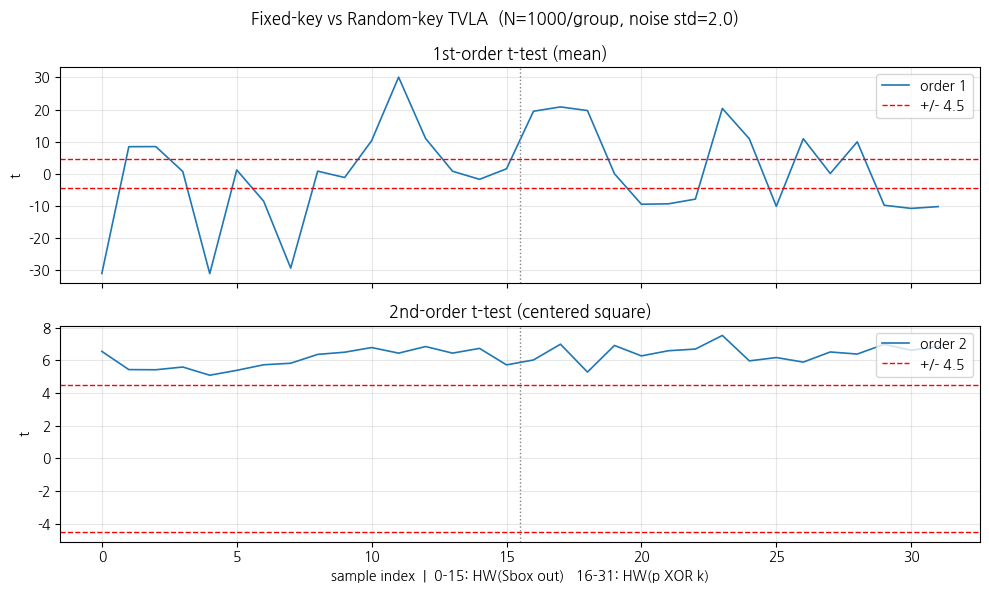

|t| > 4.5 샘플 수: 1차 23/32, 2차 32/32


In [6]:
THRESHOLD = 4.5
ns = tt.shape[1]
x_axis = np.arange(ns)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
titles = [
    "1st-order t-test (mean)",
    "2nd-order t-test (centered square)",
]
for ax, order, title in zip(axes, (0, 1), titles):
    ax.plot(x_axis, tt[order], color="C0", lw=1.2, label=f"order {order+1}")
    ax.axhline(THRESHOLD, color="r", ls="--", lw=1, label=f"+/- {THRESHOLD}")
    ax.axhline(-THRESHOLD, color="r", ls="--", lw=1)
    ax.axvline(15.5, color="gray", ls=":", lw=1)
    ax.set_ylabel("t")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")

axes[1].set_xlabel("sample index  |  0-15: HW(Sbox out)   16-31: HW(p XOR k)")
fig.suptitle(
    f"Fixed-key vs Random-key TVLA  (N={NTRACES}/group, noise std={NOISE_STD})",
    fontsize=12,
)
fig.tight_layout()
plt.show()

print(
    f"|t| > {THRESHOLD} 샘플 수: "
    f"1차 {int(np.sum(np.abs(tt[0]) > THRESHOLD))}/{ns}, "
    f"2차 {int(np.sum(np.abs(tt[1]) > THRESHOLD))}/{ns}"
)


### 노이즈를 키우면 |t|는 어떻게 되나

같은 누설 모델에서 `std`만 키우면 SNR이 나빠져 **1차 max |t|가 대체로 작아진다**.  
트레이스 수를 늘리면 다시 커질 수 있다(표준오차 \(\propto 1/\sqrt{n}\)).


In [7]:
def max_abs_t_order1(std, ntraces=1000, seed=0):
    '''노이즈 std로 짧은 TVLA를 돌리고 1차 max|t|만 반환한다.'''
    r0 = np.random.RandomState(seed)
    pt = r0.randint(0, 256, 16, dtype=np.uint8)
    fk = r0.randint(0, 256, 16, dtype=np.uint8)
    rk = np.random.RandomState(seed + 1).randint(0, 256, (ntraces, 16), dtype=np.uint8)
    tr0 = gen_hw_traces(ntraces, std, rk, pt, np.random.RandomState(seed + 2))
    tr1 = gen_hw_traces(ntraces, std, fk, pt, np.random.RandomState(seed + 3))
    tto = Ttest(d=1)
    tto.fit_u(tr0, np.zeros(ntraces, dtype=np.uint16))
    tto.fit_u(tr1, np.ones(ntraces, dtype=np.uint16))
    return float(np.nanmax(np.abs(tto.get_ttest()[0])))


print("noise std |  1st-order max|t|")
print("----------|------------------")
for s in (0.5, 2.0, 5.0, 15.0):
    print(f"{s:9.1f} | {max_abs_t_order1(s):16.2f}")


noise std |  1st-order max|t|
----------|------------------
      0.5 |            78.85
      2.0 |            38.47
      5.0 |            15.95
     15.0 |             5.21


---
## 7. 확장

### 7.1 Multivariate t-test: `MTtest`

| | `Ttest` (univariate) | `MTtest` (multivariate) |
|--|----------------------|-------------------------|
| 대상 | 샘플 시점 **하나**이다 | 여러 POI의 **곱**이다 |
| 용도 | 기본 TVLA이다 | 한 시점만 보면 약하고, **시점 조합**에 누설이 남을 때 쓴다 |

`pois`는 shape **`(d, n_pois)`**, dtype **`uint32`**이다.  
각 열은 “이 d개 샘플 인덱스의 곱”에 대한 한 번의 t-test를 정의한다.


In [8]:
from scalib.metrics import MTtest

# 인접 샘플 쌍 (0,1), (1,2), ... 로 d=2, n_pois=31인 pois를 만든다.
pois = np.array([(i, i + 1) for i in range(31)], dtype=np.uint32).T  # (2, 31)

mtt = MTtest(d=2, pois=pois)
mtt.fit_u(
    np.vstack([traces_rk, traces_fk]),
    np.concatenate([labels_rk, labels_fk]),
)
mt = mtt.get_ttest()
print("MTtest shape:", mt.shape, "  # (n_pois,)")
print("max |t|:", float(np.nanmax(np.abs(mt))))
print("t[:5]:", np.array2string(mt[:5], precision=2))


MTtest shape: (31,)   # (n_pois,)
max |t|: 2.8214235879384404
t[:5]: [ 1.03 -1.09 -0.62 -1.82 -2.82]


### 7.2 자신이 수집한 파형에 적용할 때

SCALib `Ttest`가 요구하는 것은 파일 형식이 아니라 **NumPy 배열 규약**뿐이다.

1. 집단 0 파형, 집단 1 파형을 각각 shape `(n, ns)`, dtype **`int16`**으로 준비한다.
   - 측정값이 float이면, 전체 파형에 공통인 이득(gain)을 곱해 `int16` 범위(대략 ±3만)에 들어오게 한 뒤  
     `np.clip(np.rint(...), -32768, 32767).astype(np.int16)`처럼 변환하면 된다.
   - 시점마다 다른 스케일이 필요하면 SCALib의 `scalib.preprocessing.Quantizer`를 쓸 수 있다  
     (시점별 shift/scale 추정 후 `Round((x-shift)*scale)` → `int16`). 이 노트북 범위 밖이므로 여기서는 다루지 않는다.
2. 라벨을 만든다. 집단 0은 `0`, 집단 1은 `1`이며 dtype은 `np.uint16`이다. **0과 1만 쓴다.**
3. `Ttest(d)`를 생성하고, 각 집단에 `fit_u`한 뒤, `get_ttest()`로 시점별 |t|와 관례선 ±4.5를 본다.
4. 두 집단의 **샘플 길이·스케일·트리거 정렬**을 맞춘다. 어긋나면 t가 “암호 입력 차이”가 아니라 “측정 조건 차이”를 가리킬 수 있다.

```python
# traces0, traces1: 이미 int16, shape (n, ns)
ttest = Ttest(d=2)
ttest.fit_u(traces0, np.zeros(traces0.shape[0], dtype=np.uint16))
ttest.fit_u(traces1, np.ones(traces1.shape[0], dtype=np.uint16))
t = ttest.get_ttest()  # shape (2, ns)
```


---
## 8. 요약

| 항목 | 내용 |
|------|------|
| TVLA 목적 | 두 집단 파형의 시점별 차이로 **누설 후보**를 찾는다 (키를 복원하지 않는다) |
| 핵심 API | `Ttest(d)` → `fit_u(traces, x)` → `get_ttest()` 순서로 쓴다 |
| `traces` | shape는 `(n, ns)`, dtype은 **`int16`**, 행은 한 트레이스이다 |
| `x` | shape는 `(n,)`, dtype은 **`uint16`**, 값은 0 또는 1이다 |
| 결과 | shape는 `(d, ns)`이다. 행 0은 1차, 행 1은 2차이다 |
| 임계 | \|t\|=4.5는 관례 경보선이다. 단독 합격 판정을 하지 않는다 |
| 대용량 | `fit_u`를 배치로 여러 번 호출해 누적한다 |
| 다변량 | `MTtest(d, pois)`로 POI 곱에 대한 t-test를 한다 |

이 노트북의 시뮬은 교육용 비보호 모델이다. 실제 장비 파형에서는 잡음·정렬·트리거에 따라 곡선 모양이 달라진다.  
설치·dtype·shape·`fit_u`/`get_ttest` 흐름만 지키면, 같은 절차를 자신의 데이터에 그대로 적용할 수 있다.

보조 링크: [SCALib 문서](https://scalib.readthedocs.io/) · [SCALib 저장소](https://github.com/simple-crypto/SCALib)  
링크는 참고용이며, 이 노트북만으로 TVLA 사용에 필요한 내용은 위에 모두 있다.
